# Portable Gyral Crown vs Sulcul Fundus Stats

This notebook reruns the same Mann-Whitney U tests and boxplots used in `aligned_patch_quality_heatmaps.ipynb`, but it works from the exported patch set instead of the full aligned TIFF, heatmaps, and contour pipeline.

## What is needed
- this notebook
- `gyral_crowns/`
- `sulcul_fundi/`
- `aligned_convex_concave_shared_stats_input.csv`

## Before Running
- Put the CSV in the same folder that contains `gyral_crowns/` and `sulcul_fundi/`.
- Update `PATCH_EXPORT_ROOT` in the first code cell if your copy lives somewhere else.
- Leave the folder names unchanged unless you also update the first code cell.

The compact CSV already contains the saved `spectral_energy` and `spatial_composite` values for the exported patch set, so the notebook can reproduce the same statistics without recalculating the large heatmaps.

In [ ]:
import json
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

plt.rcParams['figure.dpi'] = 140

# Main run settings live here so the portable stats pass is easy to rerun with one edit.
# Point this at the folder that contains gyral_crowns/, sulcul_fundi/, and the compact stats CSV.
PATCH_EXPORT_ROOT = Path('gyral_sulcal_patch_exports')

# If you rename or move the CSV, update this path too.
STATS_INPUT_CSV_PATH = PATCH_EXPORT_ROOT / 'aligned_convex_concave_shared_stats_input.csv'

# Keep these folder names aligned with the exported patch set unless you update them here too.
GYRAL_DIR = PATCH_EXPORT_ROOT / 'gyral_crowns'
SULCUL_DIR = PATCH_EXPORT_ROOT / 'sulcul_fundi'

# This matches the directional test used in the aligned notebook.
MANNWHITNEY_ALTERNATIVE = 'greater'

# Save the portable outputs next to the shared patch set so everything stays together.
OUTPUT_DIR = PATCH_EXPORT_ROOT / 'portable_stats_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_paths = [PATCH_EXPORT_ROOT, STATS_INPUT_CSV_PATH, GYRAL_DIR, SULCUL_DIR]
missing_paths = [path for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        'Update the paths in this cell before running the notebook. Missing: '
        + ', '.join(str(path) for path in missing_paths)
    )

print(f'Patch export root: {PATCH_EXPORT_ROOT.resolve()}')
print(f'Stats input CSV: {STATS_INPUT_CSV_PATH.resolve()}')
print(f'Gyral crowns dir: {GYRAL_DIR.resolve()}')
print(f'Sulcul fundi dir: {SULCUL_DIR.resolve()}')


Patch export root: /home/edward/edward/BME1462/data/aligned_patch_quality/B20_1998_aligned/gyral_sulcal_patch_exports
Stats input CSV: /home/edward/edward/BME1462/data/aligned_patch_quality/B20_1998_aligned/gyral_sulcal_patch_exports/aligned_convex_concave_shared_stats_input.csv
Gyral crowns dir: /home/edward/edward/BME1462/data/aligned_patch_quality/B20_1998_aligned/gyral_sulcal_patch_exports/gyral_crowns
Sulcul fundi dir: /home/edward/edward/BME1462/data/aligned_patch_quality/B20_1998_aligned/gyral_sulcal_patch_exports/sulcul_fundi


In [2]:
# Reload the shared patch table and make sure the expected columns are still there.
stats_input_df = pd.read_csv(STATS_INPUT_CSV_PATH)

required_columns = {
    'selected_curve_class',
    'export_group',
    'selected_point_id',
    'patch_index',
    'spectral_energy',
    'spatial_composite',
    'relative_image_path',
}
missing_columns = sorted(required_columns.difference(stats_input_df.columns))
if missing_columns:
    raise RuntimeError(
        'The compact stats CSV is missing required columns: ' + ', '.join(missing_columns)
    )

# Resolve the patch image paths relative to the shared root so the CSV stays portable.
stats_input_df['image_path'] = stats_input_df['relative_image_path'].map(lambda rel: PATCH_EXPORT_ROOT / rel)
missing_images = stats_input_df.loc[~stats_input_df['image_path'].map(Path.exists)].copy()
if not missing_images.empty:
    raise FileNotFoundError(
        'Some exported patch images are missing. Check PATCH_EXPORT_ROOT and the folder names. '
        f'First missing file: {missing_images.iloc[0]["image_path"]}'
    )

stats_input_df['selected_curve_class'] = stats_input_df['selected_curve_class'].astype(str)
stats_input_df['export_group'] = stats_input_df['export_group'].astype(str)

# Quick inventory of what the shared patch set contains.
class_counts = (
    stats_input_df.groupby(['selected_curve_class', 'export_group'])
    .size()
    .rename('n_images')
    .reset_index()
)

print(f'Rows loaded: {len(stats_input_df):,}')
display(class_counts)
display(
    stats_input_df[[
        'selected_curve_class',
        'export_group',
        'selected_point_id',
        'patch_index',
        'spectral_energy',
        'spatial_composite',
        'relative_image_path',
    ]].head()
)


Rows loaded: 1,000


,selected_curve_class,export_group,n_images
0,concave,sulcul_fundi,500
1,convex,gyral_crowns,500


,selected_curve_class,export_group,selected_point_id,patch_index,spectral_energy,spatial_composite,relative_image_path
0,convex,gyral_crowns,0,2154,0.091547,1.451106,gyral_crowns/gyral_crowns_point0000_patch00215...
1,convex,gyral_crowns,1,1911,0.080320,1.367414,gyral_crowns/gyral_crowns_point0001_patch00191...
2,convex,gyral_crowns,2,2407,0.085122,1.357102,gyral_crowns/gyral_crowns_point0002_patch00240...
3,convex,gyral_crowns,3,2153,0.055802,1.365448,gyral_crowns/gyral_crowns_point0003_patch00215...
4,convex,gyral_crowns,4,2406,0.073538,1.184629,gyral_crowns/gyral_crowns_point0004_patch00240...


In [3]:
# This is the portable version of the aligned boxplot step: same two metrics, same MWU summary table.
def rank_biserial_from_u(u_stat: float, n1: int, n2: int) -> float:
    return 1.0 - (2.0 * float(u_stat)) / float(n1 * n2)


def run_portable_stats(analysis_df: pd.DataFrame, mannwhitney_alternative: str) -> pd.DataFrame:
    stats_rows = []
    convex_df = analysis_df.loc[analysis_df['selected_curve_class'] == 'convex']
    concave_df = analysis_df.loc[analysis_df['selected_curve_class'] == 'concave']

    # Keep the metric list explicit so it stays locked to the aligned notebook.
    metric_specs = [
        ('spectral_energy', 'Spectral'),
        ('spatial_composite', 'Spatial'),
    ]
    if mannwhitney_alternative not in {'two-sided', 'greater', 'less'}:
        raise ValueError("mannwhitney_alternative must be 'two-sided', 'greater', or 'less'")

    for metric_name, metric_label in metric_specs:
        convex_values = convex_df[metric_name].dropna().to_numpy(dtype=float)
        concave_values = concave_df[metric_name].dropna().to_numpy(dtype=float)
        if len(convex_values) == 0 or len(concave_values) == 0:
            raise RuntimeError(f'Not enough rows to test {metric_name}.')

        u_stat, p_value = mannwhitneyu(
            convex_values,
            concave_values,
            alternative=mannwhitney_alternative,
        )
        stats_rows.append(
            {
                'metric': metric_name,
                'metric_label': metric_label,
                'mannwhitney_alternative': mannwhitney_alternative,
                'n_convex': int(len(convex_values)),
                'n_concave': int(len(concave_values)),
                'convex_mean': float(np.mean(convex_values)),
                'concave_mean': float(np.mean(concave_values)),
                'convex_std': float(np.std(convex_values, ddof=1)) if len(convex_values) > 1 else np.nan,
                'concave_std': float(np.std(concave_values, ddof=1)) if len(concave_values) > 1 else np.nan,
                'convex_median': float(np.median(convex_values)),
                'concave_median': float(np.median(concave_values)),
                'median_diff_concave_minus_convex': float(np.median(concave_values) - np.median(convex_values)),
                'mannwhitney_u': float(u_stat),
                'p_value': float(p_value),
                'rank_biserial_correlation': float(
                    rank_biserial_from_u(float(u_stat), len(convex_values), len(concave_values))
                ),
            }
        )

    stats_df = pd.DataFrame(stats_rows)
    # Keep the same small multiple-testing correction used in the aligned notebook.
    stats_df['p_value_bonferroni'] = np.minimum(stats_df['p_value'] * len(stats_df), 1.0)
    stats_df['significant_bonferroni_0p05'] = stats_df['p_value_bonferroni'] < 0.05
    return stats_df


# Same boxplot styling as the aligned notebook so the figures match when compared side by side.
def make_portable_stats_figure(analysis_df: pd.DataFrame, stats_df: pd.DataFrame, random_seed: int = 13) -> plt.Figure:
    rng = np.random.default_rng(random_seed)
    fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.8))
    fig.subplots_adjust(bottom=0.22, top=0.84, wspace=0.30)
    color_map = {'convex': '#ef4444', 'concave': '#2563eb'}
    label_order = ['convex', 'concave']

    for ax, metric_name in zip(axes, ['spectral_energy', 'spatial_composite']):
        plot_groups = [
            analysis_df.loc[analysis_df['selected_curve_class'] == curve_class, metric_name].to_numpy(dtype=float)
            for curve_class in label_order
        ]
        box = ax.boxplot(
            plot_groups,
            labels=[curve_class.title() for curve_class in label_order],
            patch_artist=True,
            widths=0.55,
            showfliers=False,
        )
        for patch, curve_class in zip(box['boxes'], label_order):
            patch.set_facecolor(color_map[curve_class])
            patch.set_alpha(0.35)
            patch.set_edgecolor(color_map[curve_class])
            patch.set_linewidth(1.5)
        for median in box['medians']:
            median.set_color('black')
            median.set_linewidth(1.4)

        # The jittered points make it easier to see the spread behind each box.
        for xpos, curve_class in enumerate(label_order, start=1):
            values = analysis_df.loc[analysis_df['selected_curve_class'] == curve_class, metric_name].to_numpy(dtype=float)
            jitter = rng.uniform(-0.09, 0.09, size=len(values))
            ax.scatter(
                np.full(len(values), xpos, dtype=float) + jitter,
                values,
                s=9,
                alpha=0.18,
                c=color_map[curve_class],
                edgecolors='none',
            )

        stats_row = stats_df.loc[stats_df['metric'] == metric_name].iloc[0]
        alternative = str(stats_row['mannwhitney_alternative'])
        if alternative == 'greater':
            test_label = 'One-sided MWU (Convex > Concave)'
        elif alternative == 'less':
            test_label = 'One-sided MWU (Convex < Concave)'
        else:
            test_label = 'Two-sided MWU'
        ax.set_title(
            f"{stats_row['metric_label']} Quality\n"
            f"{test_label}\n"
            f"p={stats_row['p_value']:.3g}, Bonf={stats_row['p_value_bonferroni']:.3g}",
            fontsize=17,
        )
        summary_text = (
            f"Convex: mean={float(stats_row['convex_mean']):.3f}, "
            f"median={float(stats_row['convex_median']):.3f}, "
            f"sd={float(stats_row['convex_std']):.3f}\n"
            f"Concave: mean={float(stats_row['concave_mean']):.3f}, "
            f"median={float(stats_row['concave_median']):.3f}, "
            f"sd={float(stats_row['concave_std']):.3f}"
        )
        ax.text(
            0.50,
            -0.14,
            summary_text,
            transform=ax.transAxes,
            ha='center',
            va='top',
            fontsize=14,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='#d1d5db'),
        )
        ax.set_ylabel(metric_name, fontsize=17)
        ax.tick_params(axis='both', labelsize=15)
        ax.grid(axis='y', alpha=0.2)

    return fig


/tmp/ipykernel_28332/1810762589.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
/tmp/ipykernel_28332/1810762589.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


,selected_curve_class,export_group,n_patches,unique_patch_count,mean_spectral,mean_spatial
0,concave,sulcul_fundi,500,500,0.068805,0.587264
1,convex,gyral_crowns,500,500,0.066153,0.973365


,metric,metric_label,mannwhitney_alternative,n_convex,n_concave,convex_mean,concave_mean,convex_std,concave_std,convex_median,concave_median,median_diff_concave_minus_convex,mannwhitney_u,p_value,rank_biserial_correlation,p_value_bonferroni,significant_bonferroni_0p05
0,spectral_energy,Spectral,greater,500,500,0.066153,0.068805,0.015842,0.02513,0.064948,0.064607,-0.000341,124660.0,5.297186e-01,0.002720,1.000000e+00,False
1,spatial_composite,Spatial,greater,500,500,0.973365,0.587264,0.617003,0.70177,0.944034,0.589448,-0.354586,168054.0,2.093172e-21,-0.344432,4.186344e-21,True


Group summary CSV: data/aligned_patch_quality/B20_1998_aligned/gyral_sulcal_patch_exports/portable_stats_outputs/portable_gyral_sulcal_group_summary.csv
Stats CSV: data/aligned_patch_quality/B20_1998_aligned/gyral_sulcal_patch_exports/portable_stats_outputs/portable_gyral_sulcal_patch_stats.csv
Stats figure: data/aligned_patch_quality/B20_1998_aligned/gyral_sulcal_patch_exports/portable_stats_outputs/portable_gyral_sulcal_patch_stats.png
Metadata JSON: data/aligned_patch_quality/B20_1998_aligned/gyral_sulcal_patch_exports/portable_stats_outputs/portable_gyral_sulcal_patch_stats_metadata.json


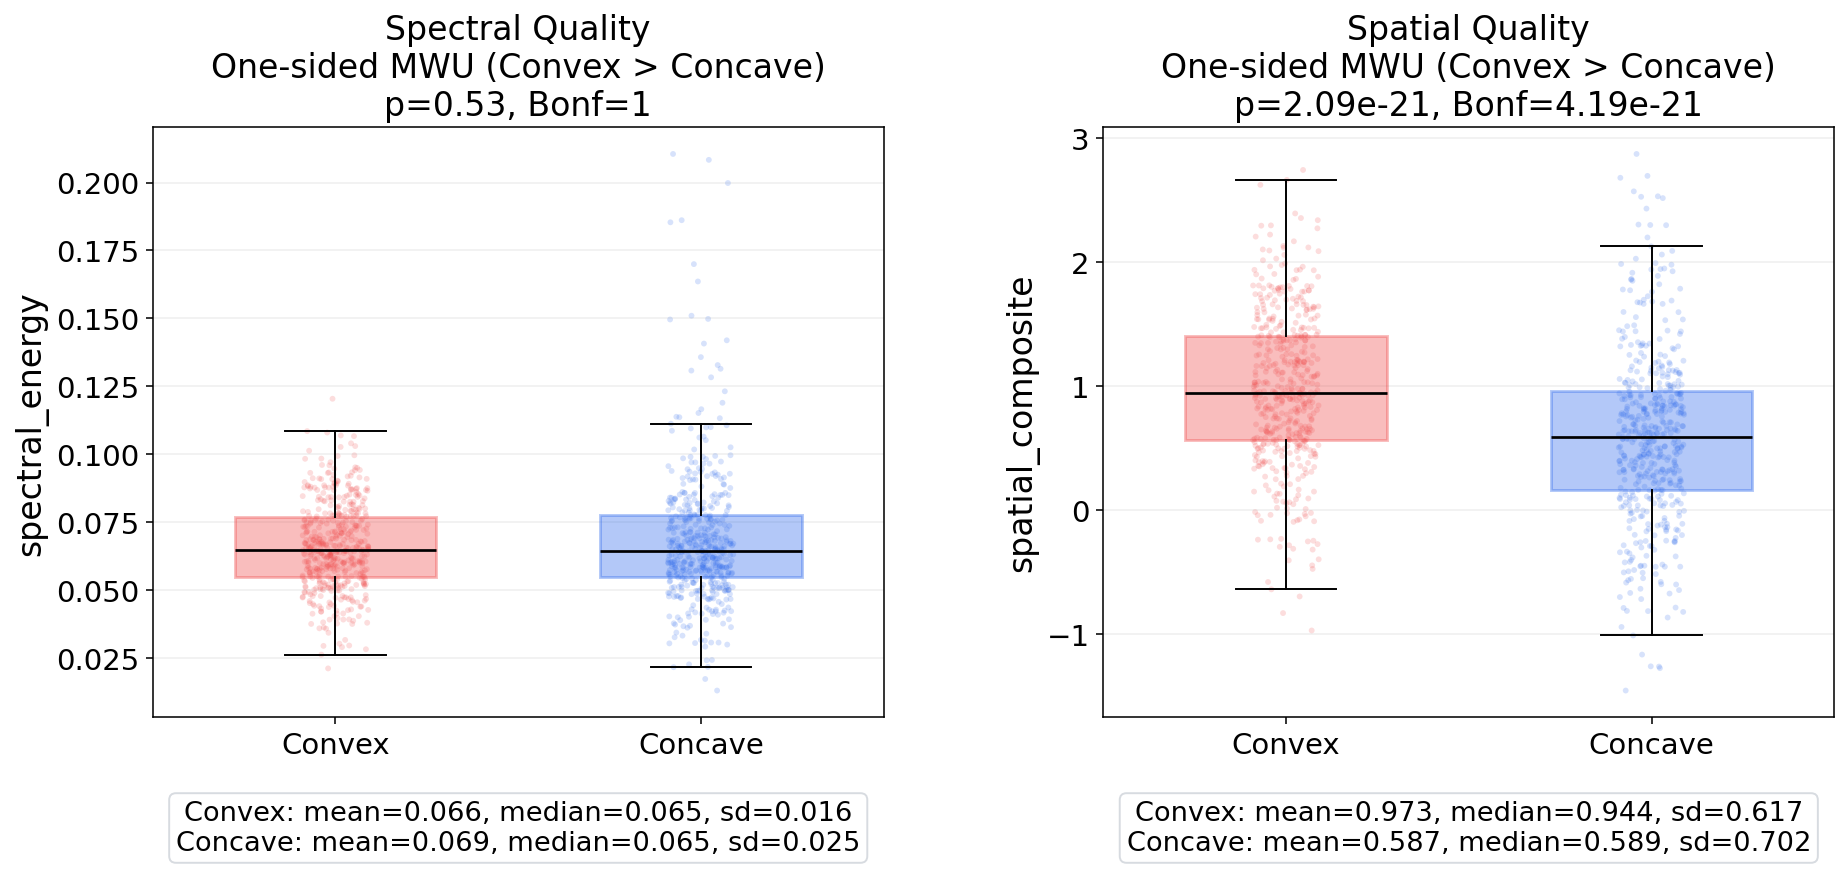

In [4]:
# The compact CSV already fixes which patches belong to each class, so we only need summary counts here.
# Group summary is just a quick sanity check that the two folders and the CSV still agree.
group_summary_df = (
    stats_input_df.groupby(['selected_curve_class', 'export_group'])
    .agg(
        n_patches=('patch_index', 'count'),
        unique_patch_count=('patch_index', 'nunique'),
        mean_spectral=('spectral_energy', 'mean'),
        mean_spatial=('spatial_composite', 'mean'),
    )
    .reset_index()
)

# Run the same stats and figure code used above, then save the portable outputs beside the shared patch set.
stats_df = run_portable_stats(stats_input_df, MANNWHITNEY_ALTERNATIVE)
stats_fig = make_portable_stats_figure(stats_input_df, stats_df, random_seed=13)

group_summary_csv_path = OUTPUT_DIR / 'portable_gyral_sulcal_group_summary.csv'
stats_csv_path = OUTPUT_DIR / 'portable_gyral_sulcal_patch_stats.csv'
stats_figure_path = OUTPUT_DIR / 'portable_gyral_sulcal_patch_stats.png'
metadata_json_path = OUTPUT_DIR / 'portable_gyral_sulcal_patch_stats_metadata.json'

group_summary_df.to_csv(group_summary_csv_path, index=False)
stats_df.to_csv(stats_csv_path, index=False)
stats_fig.savefig(stats_figure_path, dpi=200, bbox_inches='tight')

# Quick inventory of what the portable stats pass wrote to disk.
metadata = {
    'patch_export_root': str(PATCH_EXPORT_ROOT),
    'stats_input_csv_path': str(STATS_INPUT_CSV_PATH),
    'gyral_dir': str(GYRAL_DIR),
    'sulcul_dir': str(SULCUL_DIR),
    'mannwhitney_alternative': MANNWHITNEY_ALTERNATIVE,
    'row_count': int(len(stats_input_df)),
    'class_counts': stats_input_df['selected_curve_class'].value_counts().to_dict(),
    'group_summary_csv_path': str(group_summary_csv_path),
    'stats_csv_path': str(stats_csv_path),
    'stats_figure_path': str(stats_figure_path),
}
metadata_json_path.write_text(json.dumps(metadata, indent=2))

display(group_summary_df)
display(stats_df)
print(f'Group summary CSV: {group_summary_csv_path}')
print(f'Stats CSV: {stats_csv_path}')
print(f'Stats figure: {stats_figure_path}')
print(f'Metadata JSON: {metadata_json_path}')
plt.show()
